In [1]:
import numpy as np
import pandas as pd

# Datei laden
data = np.load("/Users/Joachim/Documents/TU/project01-smartwatch-regression/data/smartwatch_data.npy")

# Typ & Form anzeigen
print(type(data))
print(data.shape)

df = pd.DataFrame(data)
df.head

<class 'numpy.ndarray'>
(100, 8)


<bound method NDFrame.head of       0    1      2      3      4         5    6      7
0   8.0  0.0  108.0  126.0   80.0  0.581689  2.0  409.0
1   8.0  0.0  120.0  148.0   70.0  0.298044  2.0  479.0
2   7.5  8.0   99.0  131.0   55.0  0.249333  2.0  340.0
3   8.0  8.0  109.0  175.0   50.0  0.313333  2.0  282.0
4   6.5  0.0  116.0  149.0   45.0  0.406000  2.0  406.0
..  ...  ...    ...    ...    ...       ...  ...    ...
95  8.0  8.0   91.0  125.0  100.0  1.000000  3.0  604.0
96  8.0  8.0   91.0  110.0   30.0  0.010267  1.0   77.0
97  8.0  8.0   92.0  112.0  110.0  0.488889  3.0  500.0
98  8.0  0.0   85.0  101.0   80.0  0.355556  3.0  500.0
99  8.0  5.0   88.0  104.0   85.0  0.188889  3.0  500.0

[100 rows x 8 columns]>

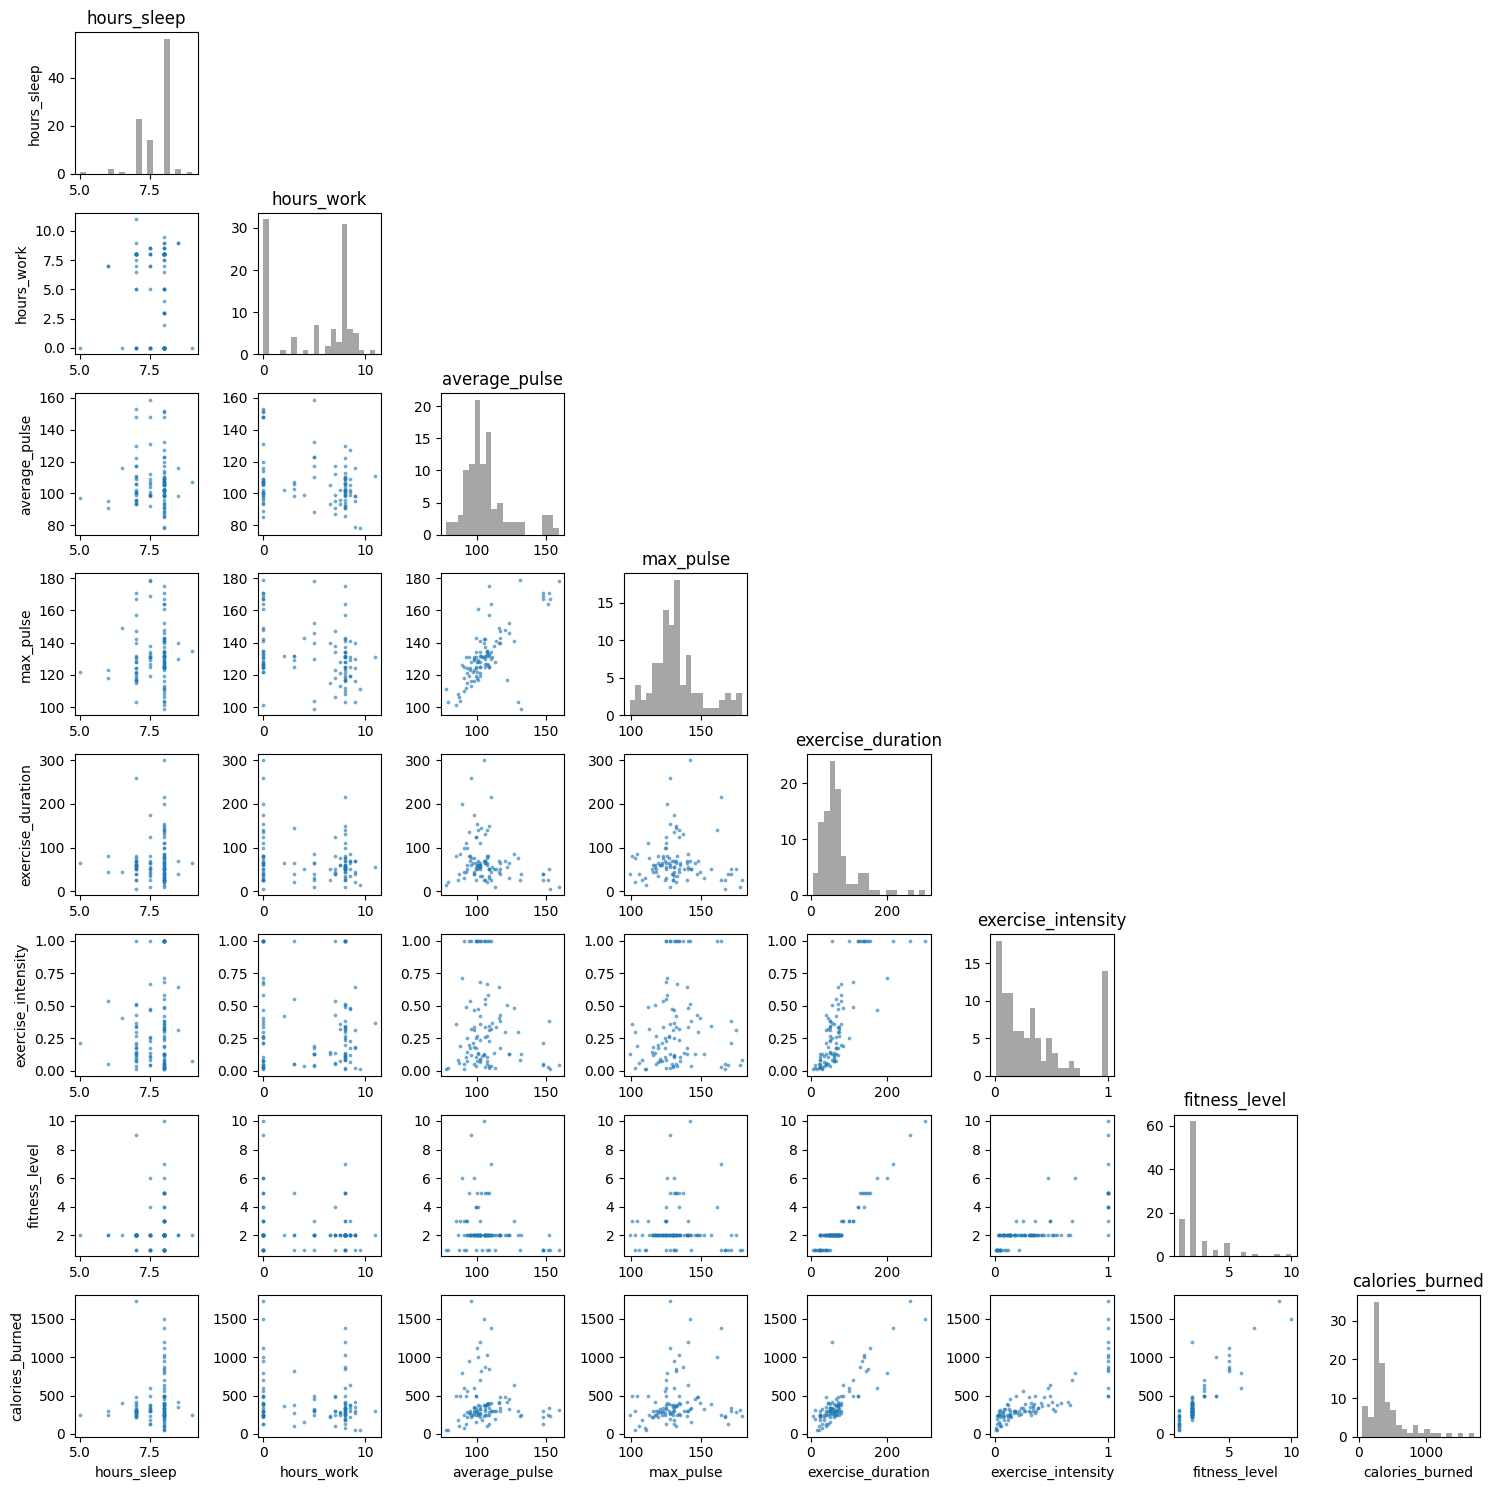

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from typing import Callable
from sklearn.inspection import DecisionBoundaryDisplay
from linear_regression import compute_polynomial_design_matrix

def pairplot(data: np.ndarray, feature_names: list[str]) -> None:
    """
    Create a pairplot of the given data.
    :param data: 2D array of shape (N, D) that represents the data matrix
    :param feature_names: List of feature names
    :return: None
    """
    num_features = data.shape[1]
    fig, axes = plt.subplots(num_features, num_features, figsize=(15, 15))
    for i in range(num_features):
        for j in range(num_features):
            if i == j:
                axes[i, j].hist(data[:, i], bins=20, color='gray', alpha=0.7)
                axes[i, j].set_title(feature_names[i])
            elif i > j:
                axes[i, j].scatter(data[:, j], data[:, i], alpha=0.5, s=3)
            else:
                # Upper triangle: hide plots
                axes[i, j].set_visible(False)
            if i == num_features - 1:
                axes[i, j].set_xlabel(feature_names[j])
            if j == 0:
                axes[i, j].set_ylabel(feature_names[i])
    plt.tight_layout()
    plt.show()

feature_names = [
    "hours_sleep", 
    "hours_work", 
    "average_pulse", 
    "max_pulse", 
    "exercise_duration", 
    "exercise_intensity", 
    "fitness_level", 
    "calories_burned"
]

pairplot(data, feature_names)

In [3]:
x = data[:,4] # shape (100,)
y = data[:, 7] # shape (100,)

X = data[:, 4].reshape(-1,1) # shape (100, 1)
y = data[:, 7].reshape(-1,1) # shape (100, 1)

X_design = np.hstack([X,
                      np.ones((X.shape[0], 1))])

theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
print(theta)



[[ 5.22109411]
 [46.23868585]]


In [4]:
def fit_univariate_lin_model(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    :param x: 1D array that contains the feature of each subject
    :param y: 1D array that contains the target of each subject
    :return: the parameter vector theta^* that minimizes the loss \mathcal{L}_U(theta)
    """

    N = x.size
    assert N > 1, "There must be at least 2 points given!"
    # TODO: Implement the 1D case of linear regression from the assigment sheet (see also slides from practicals)
    X = x.reshape(-1, 1) # shape (100, 1)
    y = y.reshape(-1, 1) # shape (100, 1)

    X_design = np.hstack([np.ones((X.shape[0], 1)), X])

    theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

    w = theta[1,0]
    b = theta[0,0]
    return np.array([b, w])

fit_univariate_lin_model(data[:,4], data[:,7])

array([46.23868585,  5.22109411])

In [5]:
def univariate_loss(x: np.ndarray, y: np.ndarray, theta: np.ndarray) -> float:
   """
   :param x: 1D array that represents the feature vector
   :param y: 1D array that represents the target vector
   :param theta: 1D array that represents the parameter vector theta = (b, w)
   :return: a scalar that represents the loss \mathcal{L}_U(theta)
   """
   # TODO: Implement the univariate loss \mathcal{L}_U(theta) (as specified in Equation 1)
   X = x.reshape(-1, 1) # shape (100, 1)
   y = y.reshape(-1, 1) # shape (100, 1)

   X_design = np.hstack([np.ones((X.shape[0], 1)), X])

   theta = theta.reshape(-1,1)
   
   y_pred = X_design @ theta
   loss = np.mean((y - y_pred)**2)

   return loss

univariate_loss(data[:,4], data[:,7], fit_univariate_lin_model(data[:,4], data[:,7]))

np.float64(21843.02631680113)